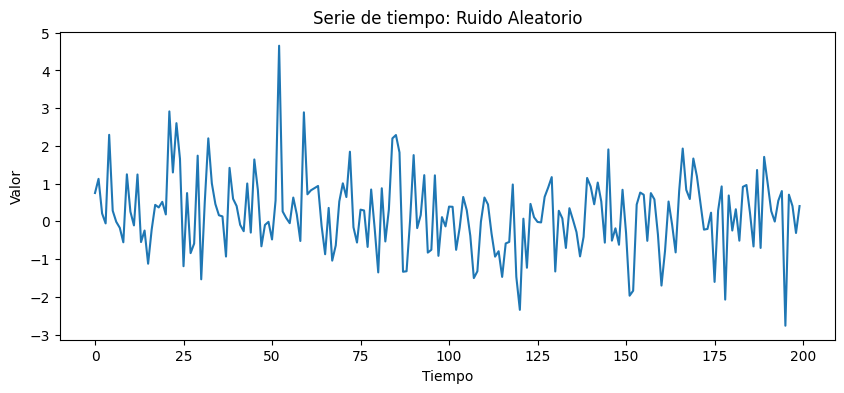

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# tamaño de la serie
T = 200

# tiempo
t = np.arange(T)

# generar ruido aleatorio
x = np.random.normal(0, 1, T)

# graficar
plt.figure(figsize=(10,4))
plt.plot(t, x)
plt.title("Serie de tiempo: Ruido Aleatorio")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.show()

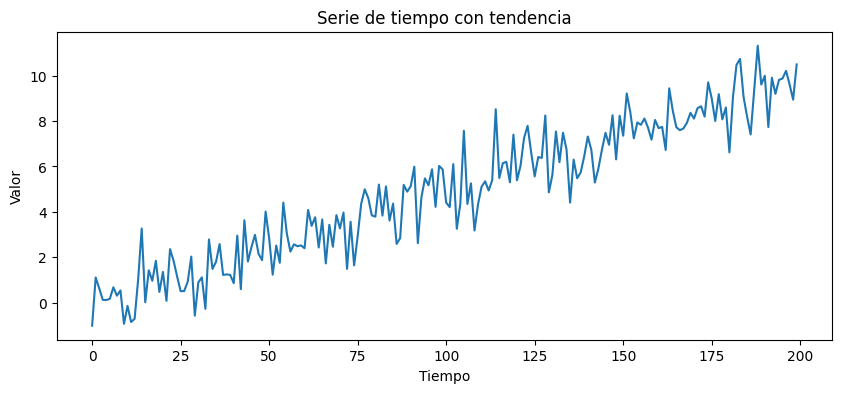

In [13]:
trend = 0.05 * t
noise = np.random.normal(0, 1, T)

x = trend + noise

plt.figure(figsize=(10,4))
plt.plot(t, x)
plt.title("Serie de tiempo con tendencia")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.show()

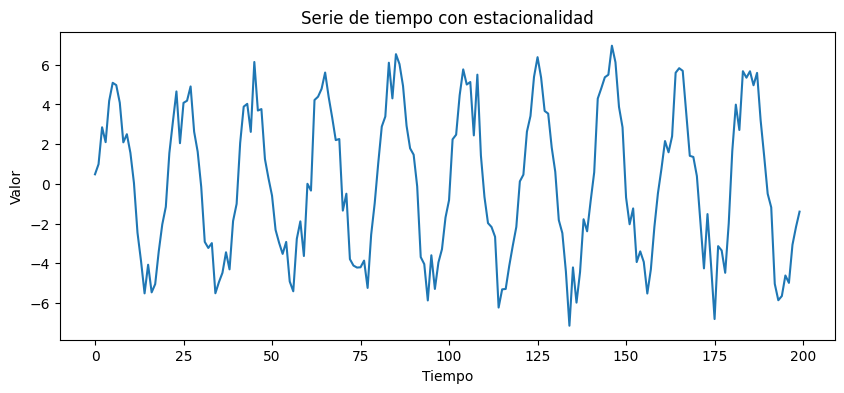

In [14]:
A = 5
omega = 2*np.pi/20

seasonal = A * np.sin(omega * t)
noise = np.random.normal(0, 1, T)

x = seasonal + noise

plt.figure(figsize=(10,4))
plt.plot(t, x)
plt.title("Serie de tiempo con estacionalidad")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.show()

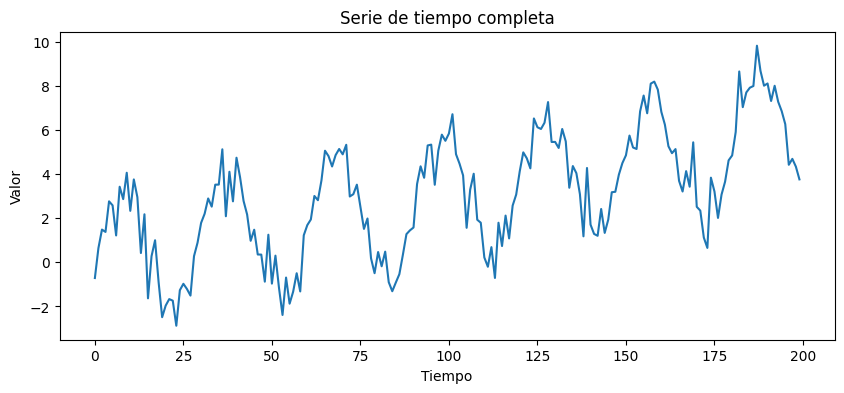

In [15]:
trend = 0.03 * t
seasonal = 3 * np.sin(2*np.pi*t/30)
noise = np.random.normal(0, 0.8, T)

x = trend + seasonal + noise

plt.figure(figsize=(10,4))
plt.plot(t, x)
plt.title("Serie de tiempo completa")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.show()

In [16]:
FILEID="1BidLKcEXF6h-LKKWixtKmQ_g5hgvrkgd"

!wget --load-cookies /tmp/cookies.txt \
"https://docs.google.com/uc?export=download&confirm=$(wget --quiet --save-cookies /tmp/cookies.txt \
--keep-session-cookies --no-check-certificate \
'https://docs.google.com/uc?export=download&id='$FILEID -O- | \
sed -rn 's/.*confirm=([0-9A-Za-z_]+).*/\1/p')&id=$FILEID" \
-O datos.xlsx && rm -rf /tmp/cookies.txt

--2026-02-28 04:46:05--  https://docs.google.com/uc?export=download&confirm=&id=1BidLKcEXF6h-LKKWixtKmQ_g5hgvrkgd
Resolving docs.google.com (docs.google.com)... 173.194.217.100, 173.194.217.113, 173.194.217.138, ...
Connecting to docs.google.com (docs.google.com)|173.194.217.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1BidLKcEXF6h-LKKWixtKmQ_g5hgvrkgd&export=download [following]
--2026-02-28 04:46:05--  https://drive.usercontent.google.com/download?id=1BidLKcEXF6h-LKKWixtKmQ_g5hgvrkgd&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.98.132, 2607:f8b0:400c:c1a::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.98.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 25514 (25K) [application/octet-stream]
Saving to: ‘datos.xlsx’

datos.xlsx          100%[===================>]  24.92K  --.-KB/

In [63]:
import pandas as pd
Xdata = pd.read_excel('datos.xlsx')

In [64]:
Xdata

,Año,Mes,TGP,TD,salarios reales,Indicador de Seguimiento a la Economía,imporenta real,iva real,Tasa de intervención de política monetaria (%)
0,2005,1,60.366114,13.218313,6.758193e+05,60.446953,2.497004e+06,3.059284e+06,6.50
1,2005,2,60.263780,14.229214,6.690635e+05,59.874788,3.359053e+06,6.227137e+05,6.50
2,2005,3,59.959982,12.948364,6.639401e+05,60.814287,1.811013e+06,2.631880e+06,6.50
3,2005,4,60.084099,12.061151,6.609494e+05,62.802666,6.214567e+06,6.704096e+05,6.50
4,2005,5,60.262330,12.305398,6.583261e+05,62.803459,2.521990e+06,2.579707e+06,6.50
...,...,...,...,...,...,...,...,...,...
223,2023,8,64.500000,9.400000,1.107656e+06,121.597715,4.162911e+06,1.746622e+06,13.25
224,2023,9,64.300000,9.700000,1.107656e+06,119.185327,4.073144e+06,1.717562e+06,13.25
225,2023,10,63.600000,10.000000,1.107656e+06,118.644553,3.983376e+06,1.688503e+06,13.25
226,2023,11,64.000000,10.200000,1.107656e+06,124.858204,3.893609e+06,1.659444e+06,13.25


In [65]:
Xdata.rename(columns={'Año': 'Year', 'Mes':'Month', 'TGP':'GPR',
       'salarios reales':'RS', 'Indicador de Seguimiento a la Economía':'EMI',
       'imporenta real':'RIT', 'iva real':'RVT',
       'Tasa de intervención de política monetaria (%)':'MPIR','TD':'UR'},inplace=True) #'TD-1':'UR-1','TD-2':'UR-2','TD-3':'UR-3','TD':'UR'}, inplace=True)



In [66]:
df=Xdata.copy()

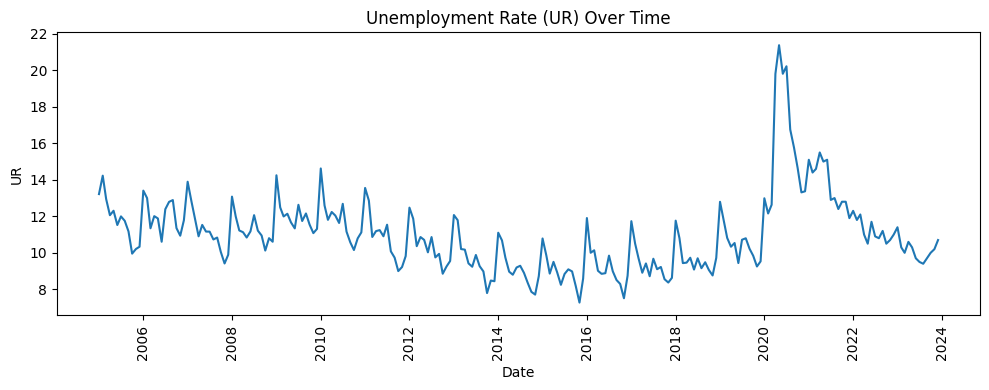

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a datetime column from Year and Month
df["date"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-01")

# Sort by date
df = df.sort_values("date")

# Plot only the unemployment rate (UR)
plt.figure(figsize=(10,4))
plt.plot(df["date"], df["UR"])
plt.title("Unemployment Rate (UR) Over Time")
plt.xlabel("Date")
plt.ylabel("UR")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


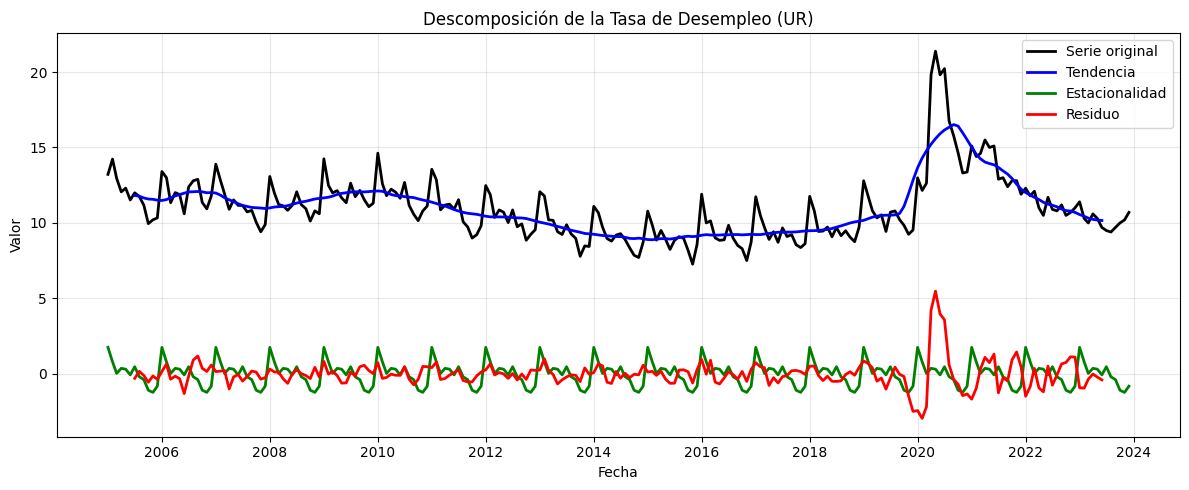

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose

# Tomamos la serie de desempleo
serie = Xdata['UR']

# Descomposición aditiva
decomposition = seasonal_decompose(serie, model='additive', period=12)

trend = decomposition.trend
seasonal = decomposition.seasonal
residuo = decomposition.resid


# ----------------------------
# Una sola figura
# ----------------------------
plt.figure(figsize=(12,5))

plt.plot(df["date"], serie, label="Serie original", color="black", linewidth=2)
plt.plot(df["date"], trend, label="Tendencia", color="blue", linewidth=2)
plt.plot(df["date"], seasonal, label="Estacionalidad", color="green", linewidth=2)
plt.plot(df["date"], residuo, label="Residuo", color="red", linewidth=2)

# formato fechas
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title("Descomposición de la Tasa de Desempleo (UR)")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

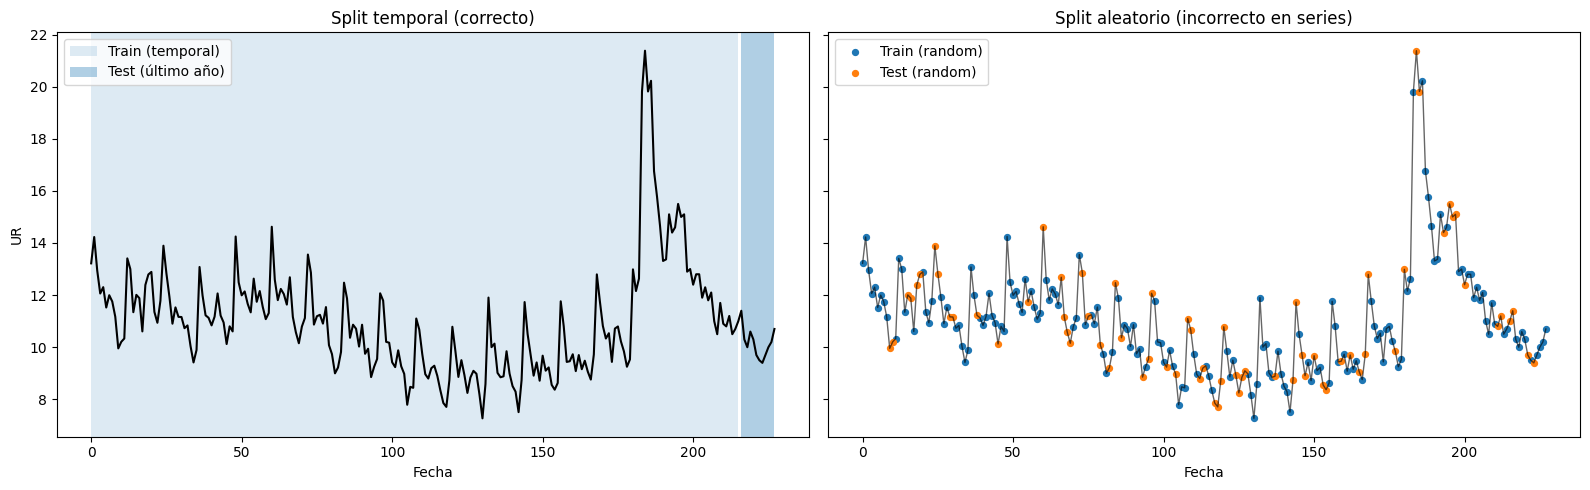

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# =========================
# 0) Serie (UR) y orden temporal
# =========================
Xdata = Xdata.sort_index()
serie = Xdata["UR"].astype(float)


# =========================
# 1) Split temporal para el modelo final (lo que quieres)
#    Train = todo menos último año
#    Test  = último año
# =========================
test_months = 12
y_train = serie.iloc[:-test_months]
y_test  = serie.iloc[-test_months:]

# =========================
# 2) Split aleatorio convencional (solo para contraste)
# =========================
idx = np.arange(len(serie))
train_idx, test_idx = train_test_split(idx, test_size=0.30, shuffle=True, random_state=42)

# =========================
# 3) Figura 1x2 (comparación)
# =========================
fig, axs = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# --------------------------------------
# (A) Split temporal correcto (final)
# --------------------------------------
axs[0].plot(serie.index, serie.values, color="black", linewidth=1.5)

axs[0].axvspan(y_train.index[0], y_train.index[-1], alpha=0.15, label="Train (temporal)")
axs[0].axvspan(y_test.index[0],  y_test.index[-1],  alpha=0.35, label="Test (último año)")

axs[0].set_title("Split temporal (correcto)")
axs[0].set_xlabel("Fecha")
axs[0].set_ylabel("UR")
axs[0].legend()

# --------------------------------------
# (B) Split aleatorio (incorrecto)
# --------------------------------------
axs[1].plot(serie.index, serie.values, color="black", linewidth=1.0, alpha=0.6)

axs[1].scatter(serie.index[train_idx], serie.iloc[train_idx], s=18, label="Train (random)")
axs[1].scatter(serie.index[test_idx],  serie.iloc[test_idx],  s=18, label="Test (random)")

axs[1].set_title("Split aleatorio (incorrecto en series)")
axs[1].set_xlabel("Fecha")
axs[1].legend()

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


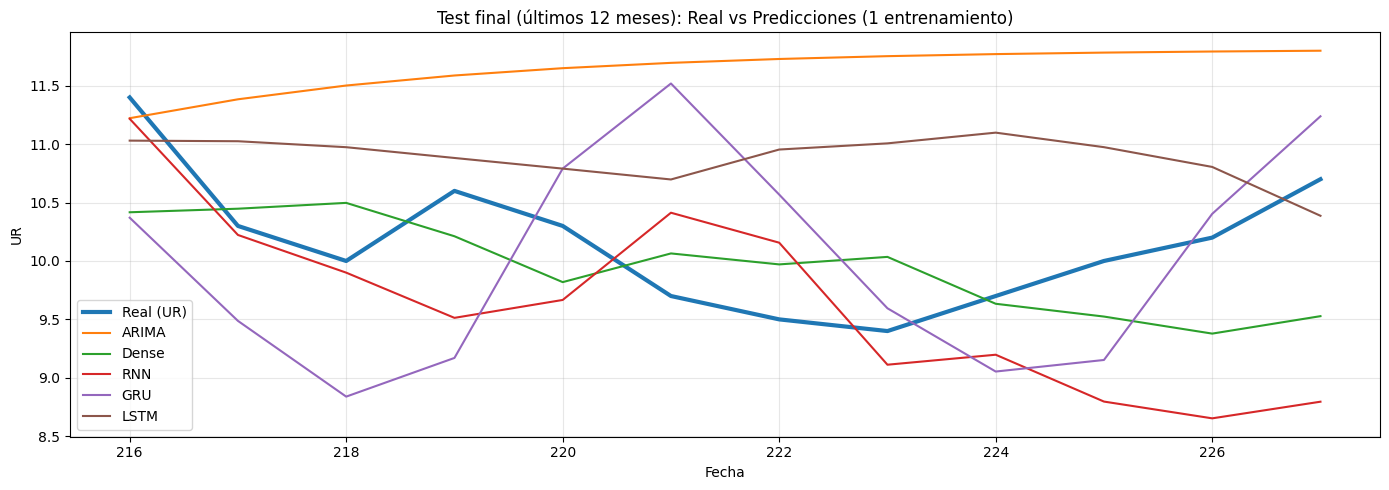

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import layers, models

# =========================
# 0) Serie (UR) mensual
# =========================
Xdata = Xdata.sort_index()
serie = Xdata["UR"].astype(float).copy()

# =========================
# 1) Split único: TODO menos último año (train) vs último año (test)
# =========================
test_months = 12
y_train = serie.iloc[:-test_months]
y_test  = serie.iloc[-test_months:]

if len(y_train) < 24:
    raise ValueError("Muy pocos datos en train. Revisa la serie o reduce test_months.")

# =========================
# 2) ARIMA (clásico)
# =========================
arima_order = (1, 1, 1)  # baseline
arima_fit = ARIMA(y_train, order=arima_order).fit()

pred_arima = arima_fit.forecast(steps=len(y_test))
pred_arima = pd.Series(pred_arima.values, index=y_test.index, name="ARIMA")

# =========================
# 3) Redes (Dense, RNN, GRU, LSTM) — 1 entrenamiento
#    Entrenan SOLO con y_train, y predicen 12 meses (multi-step recursivo)
# =========================
tf.random.set_seed(42)
np.random.seed(42)

lookback = 24  # recomendado con series mensuales; puedes probar 12/24/36
if len(y_train) <= lookback:
    lookback = min(12, len(y_train) - 1)

# Escalar SOLO con train
scaler = StandardScaler()
train_scaled = scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()

def make_supervised(arr, lb):
    X, Y = [], []
    for i in range(lb, len(arr)):
        X.append(arr[i-lb:i])
        Y.append(arr[i])
    return np.array(X), np.array(Y)

Xtr, ytr = make_supervised(train_scaled, lookback)
Xtr_dense = Xtr
Xtr_seq   = Xtr[..., None]

def build_dense(lb):
    m = models.Sequential([
        layers.Input(shape=(lb,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),
    ])
    m.compile(optimizer="adam", loss="mse")
    return m

def build_rnn(lb):
    m = models.Sequential([
        layers.Input(shape=(lb, 1)),
        layers.SimpleRNN(32),
        layers.Dense(1),
    ])
    m.compile(optimizer="adam", loss="mse")
    return m

def build_gru(lb):
    m = models.Sequential([
        layers.Input(shape=(lb, 1)),
        layers.GRU(32),
        layers.Dense(1),
    ])
    m.compile(optimizer="adam", loss="mse")
    return m

def build_lstm(lb):
    m = models.Sequential([
        layers.Input(shape=(lb, 1)),
        layers.LSTM(32),
        layers.Dense(1),
    ])
    m.compile(optimizer="adam", loss="mse")
    return m

EPOCHS = 200
BATCH  = 16
cb = [tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)]

dense = build_dense(lookback)
dense.fit(Xtr_dense, ytr, epochs=EPOCHS, batch_size=BATCH, verbose=0, callbacks=cb)

rnn = build_rnn(lookback)
rnn.fit(Xtr_seq, ytr, epochs=EPOCHS, batch_size=BATCH, verbose=0, callbacks=cb)

gru = build_gru(lookback)
gru.fit(Xtr_seq, ytr, epochs=EPOCHS, batch_size=BATCH, verbose=0, callbacks=cb)

lstm = build_lstm(lookback)
lstm.fit(Xtr_seq, ytr, epochs=EPOCHS, batch_size=BATCH, verbose=0, callbacks=cb)

def forecast_recursive(model, last_window_scaled, steps, is_seq):
    preds = []
    w = last_window_scaled.copy()
    for _ in range(steps):
        x = w.reshape(1, -1, 1) if is_seq else w.reshape(1, -1)
        yhat = model.predict(x, verbose=0).ravel()[0]
        preds.append(yhat)
        w = np.roll(w, -1)
        w[-1] = yhat
    return np.array(preds)

last_window = train_scaled[-lookback:]  # SOLO train

pred_dense_s = forecast_recursive(dense, last_window, len(y_test), is_seq=False)
pred_rnn_s   = forecast_recursive(rnn,   last_window, len(y_test), is_seq=True)
pred_gru_s   = forecast_recursive(gru,   last_window, len(y_test), is_seq=True)
pred_lstm_s  = forecast_recursive(lstm,  last_window, len(y_test), is_seq=True)

pred_dense = scaler.inverse_transform(pred_dense_s.reshape(-1, 1)).ravel()
pred_rnn   = scaler.inverse_transform(pred_rnn_s.reshape(-1, 1)).ravel()
pred_gru   = scaler.inverse_transform(pred_gru_s.reshape(-1, 1)).ravel()
pred_lstm  = scaler.inverse_transform(pred_lstm_s.reshape(-1, 1)).ravel()

pred_dense = pd.Series(pred_dense, index=y_test.index, name="Dense")
pred_rnn   = pd.Series(pred_rnn,   index=y_test.index, name="RNN")
pred_gru   = pd.Series(pred_gru,   index=y_test.index, name="GRU")
pred_lstm  = pd.Series(pred_lstm,  index=y_test.index, name="LSTM")

# =========================
# 4) Gráfica final (solo último año)
# =========================
plt.figure(figsize=(14, 5))

plt.plot(y_test.index, y_test.values, linewidth=3, label="Real (UR)")
plt.plot(pred_arima.index, pred_arima.values, label="ARIMA")
plt.plot(pred_dense.index, pred_dense.values, label="Dense")
plt.plot(pred_rnn.index,   pred_rnn.values,   label="RNN")
plt.plot(pred_gru.index,   pred_gru.values,   label="GRU")
plt.plot(pred_lstm.index,  pred_lstm.values,  label="LSTM")

plt.title("Test final (últimos 12 meses): Real vs Predicciones (1 entrenamiento)")
plt.xlabel("Fecha")
plt.ylabel("UR")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()